# 

In [1]:
# imports 
from ucimlrepo import fetch_ucirepo 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [2]:
# pandas setup 
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [3]:
# fetch data
parkinsons = fetch_ucirepo(id=174) 
features = parkinsons.data.features 
targets = parkinsons.data.targets 

# turn into pandas df
data = pd.concat([features, targets], axis=1)
data.head()
print(data.shape)

(195, 23)


In [4]:
data.dtypes

MDVP:Fo         float64
MDVP:Fhi        float64
MDVP:Flo        float64
MDVP:Jitter     float64
MDVP:Jitter     float64
MDVP:RAP        float64
MDVP:PPQ        float64
Jitter:DDP      float64
MDVP:Shimmer    float64
MDVP:Shimmer    float64
Shimmer:APQ3    float64
Shimmer:APQ5    float64
MDVP:APQ        float64
Shimmer:DDA     float64
NHR             float64
HNR             float64
RPDE            float64
DFA             float64
spread1         float64
spread2         float64
D2              float64
PPE             float64
status            int64
dtype: object

In [5]:
# check for null
print(data.isnull().sum().sum())
# check for duplicates
print(data.duplicated().sum())

0
0


# preprocessing 

In [6]:
# remove duplicate columns
# all data, where columns not duplicated, transpose to use row duplicate function on columns
data = data.loc[:, ~data.T.duplicated()]
data.head()

,MDVP:Fo,MDVP:Fhi,MDVP:Flo,MDVP:Jitter,MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE,status
0,119.992,157.302,74.997,0.00784,0.00370,0.00554,0.01109,0.04374,0.02182,0.03130,0.02971,0.06545,0.02211,21.033,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654,1
1,122.400,148.650,113.819,0.00968,0.00465,0.00696,0.01394,0.06134,0.03134,0.04518,0.04368,0.09403,0.01929,19.085,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674,1
2,116.682,131.111,111.555,0.01050,0.00544,0.00781,0.01633,0.05233,0.02757,0.03858,0.03590,0.08270,0.01309,20.651,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634,1
3,116.676,137.871,111.366,0.00997,0.00502,0.00698,0.01505,0.05492,0.02924,0.04005,0.03772,0.08771,0.01353,20.644,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975,1
4,116.014,141.781,110.655,0.01284,0.00655,0.00908,0.01966,0.06425,0.03490,0.04825,0.04465,0.10470,0.01767,19.649,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335,1


In [7]:
data.shape

(195, 21)

In [8]:
# rename columns to lowercase
data.columns = data.columns.str.lower()
data.head(2)

,mdvp:fo,mdvp:fhi,mdvp:flo,mdvp:jitter,mdvp:rap,mdvp:ppq,jitter:ddp,mdvp:shimmer,shimmer:apq3,shimmer:apq5,mdvp:apq,shimmer:dda,nhr,hnr,rpde,dfa,spread1,spread2,d2,ppe,status
0,119.992,157.302,74.997,0.00784,0.00370,0.00554,0.01109,0.04374,0.02182,0.03130,0.02971,0.06545,0.02211,21.033,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654,1
1,122.400,148.650,113.819,0.00968,0.00465,0.00696,0.01394,0.06134,0.03134,0.04518,0.04368,0.09403,0.01929,19.085,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674,1


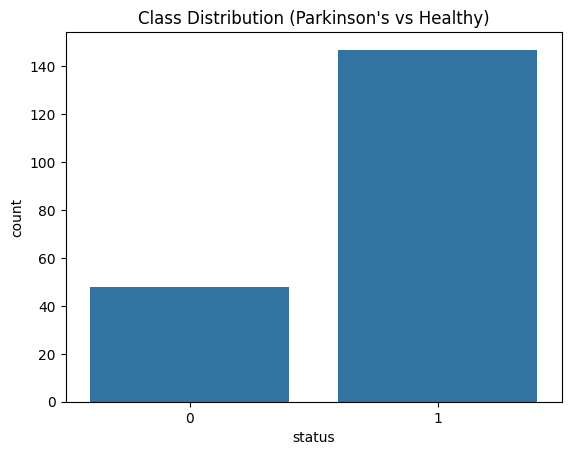

In [9]:
# Class distribution
sns.countplot(data=data, x='status')
plt.title('Class Distribution (Parkinson\'s vs Healthy)')
plt.show()

In [10]:
# check target imbalance
print(data['status'].value_counts())

status
1    147
0     48
Name: count, dtype: int64


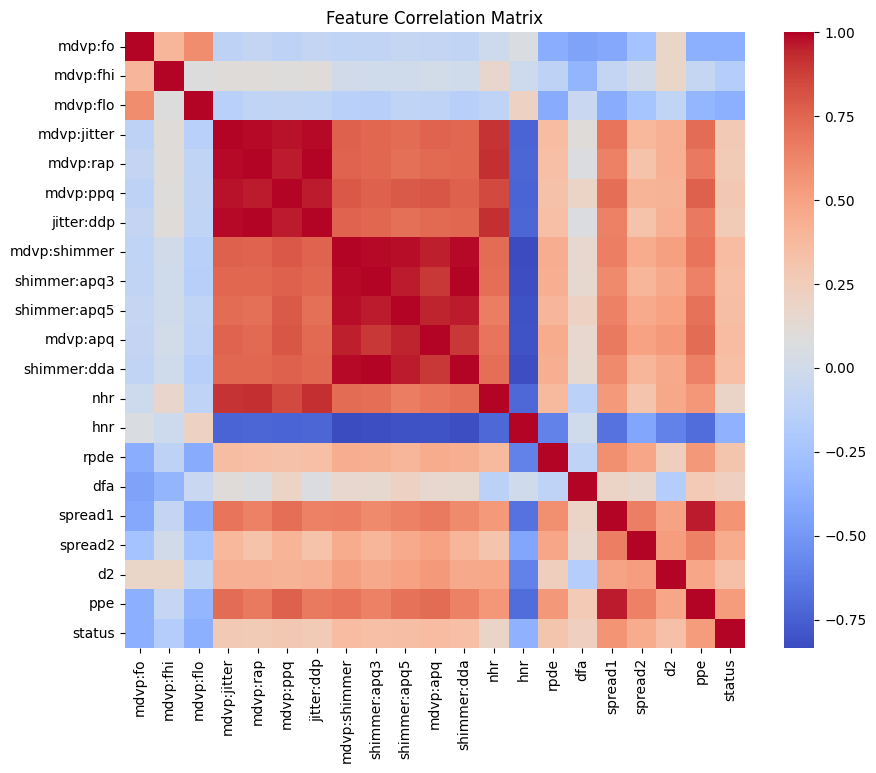

In [11]:
# Calculate correlation matrix
corr = data.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=False, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()


In [12]:
corr_matrix = data.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
data = data.drop(columns=to_drop)
print(f"Removed {len(to_drop)} highly correlated columns: {to_drop}")
print(f"Remaining shape: {data.shape}")

Removed 8 highly correlated columns: ['mdvp:rap', 'mdvp:ppq', 'jitter:ddp', 'shimmer:apq3', 'shimmer:apq5', 'mdvp:apq', 'shimmer:dda', 'ppe']
Remaining shape: (195, 13)


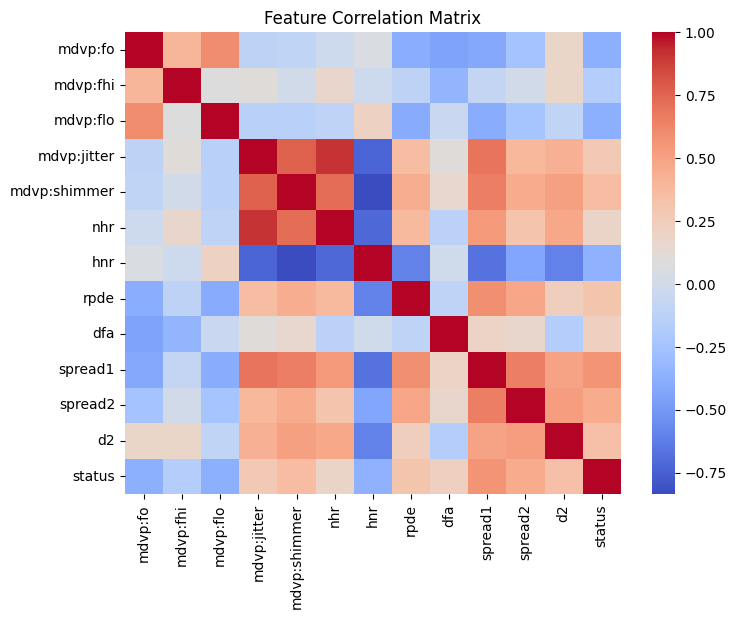

In [13]:
corr = data.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=False, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

In [14]:
data.shape

(195, 13)

spread1         0.564838
spread2         0.454842
mdvp:shimmer    0.367430
d2              0.340232
rpde            0.308567
Name: status, dtype: float64


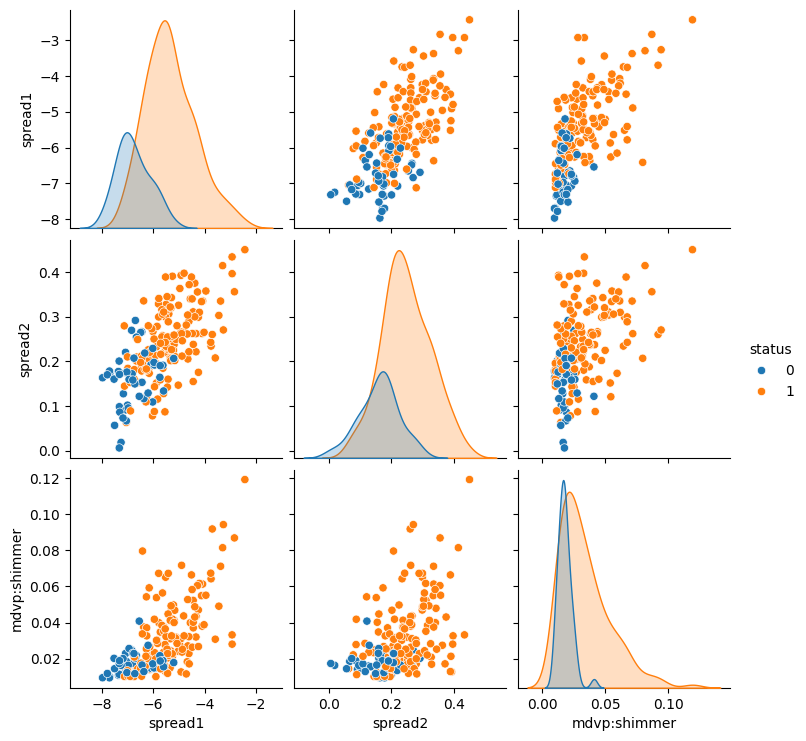

In [15]:
# Correlation with target
target_corr = data.corr()['status'].drop('status').sort_values(ascending=False)
print(target_corr.head())

# Visualize top 3 correlated features
top_features = target_corr.head(3).index.tolist()
sns.pairplot(data, vars=top_features, hue='status')
plt.show()

# model preprocessing

In [16]:
# Feature/target split
X = data.drop(columns='status')
y = data['status']

# Stratified train/test split (3:1 imbalance)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [17]:
# Calculate class imbalance ratio
scale_pos_weight = y_train.value_counts()[1] / y_train.value_counts()[0]
scale_pos_weight

3.1052631578947367

In [18]:
# Train model
model = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight
)
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [19]:
# Predict
y_pred = model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8974358974358975

Confusion Matrix:
 [[ 8  2]
 [ 2 27]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.80      0.80        10
           1       0.93      0.93      0.93        29

    accuracy                           0.90        39
   macro avg       0.87      0.87      0.87        39
weighted avg       0.90      0.90      0.90        39



- 2 FN one missed, 2 FP false predictions

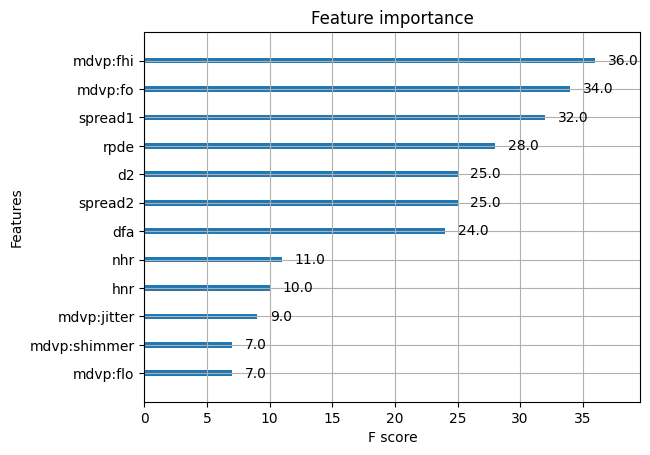

In [20]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plot_importance(model, max_num_features=None)
plt.show()


In [21]:
# Pickle model
with open('xgboost_baseline_model.pkl', 'wb') as f:
    pickle.dump(model, f)

In [22]:
# reduced feature model

In [23]:
top_features = ['mdvp:fhi', 'mdvp:fo', 'spread1', 'rpde', 'd2', 'spread2']
X_top = X[top_features]

In [24]:
X_train_top, X_test_top, y_train, y_test = train_test_split(X_top, y, test_size=0.2, random_state=42, stratify=y)

model_top = XGBClassifier(
    scale_pos_weight=2.80,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
model_top.fit(X_train_top, y_train)
y_pred_top = model_top.predict(X_test_top)


In [25]:
# Predict
y_pred = model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.8974358974358975

Confusion Matrix:
 [[ 8  2]
 [ 2 27]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.80      0.80        10
           1       0.93      0.93      0.93        29

    accuracy                           0.90        39
   macro avg       0.87      0.87      0.87        39
weighted avg       0.90      0.90      0.90        39



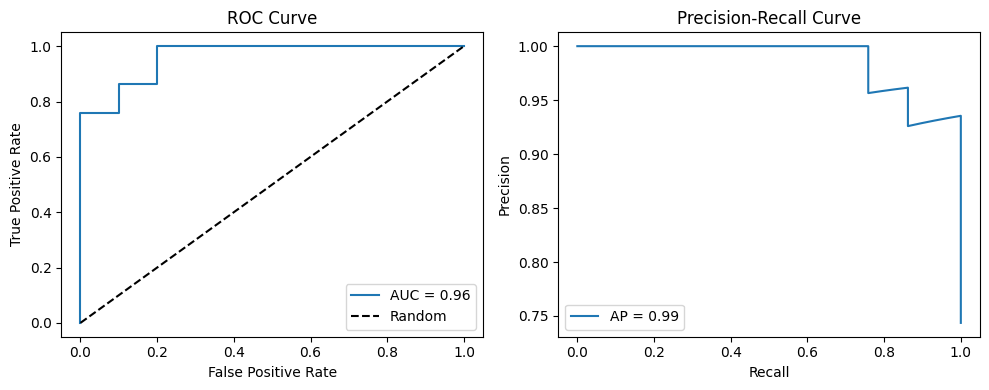

In [26]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Get predicted probabilities
y_proba = model.predict_proba(X_test)[:, 1]  # Probabilities for class 1

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

# --- PR Curve ---
precision, recall, _ = precision_recall_curve(y_test, y_proba)
avg_precision = average_precision_score(y_test, y_proba)

plt.subplot(1, 2, 2)
plt.plot(recall, precision, label=f'AP = {avg_precision:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()

plt.tight_layout()
plt.show()


# hyperparameter tuning on 6 top features

In [29]:
with open('parkinsons_xgb_top6.pkl', 'wb') as f:
    pickle.dump(model, f)

In [27]:
# hyperparameter tuned model
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
import numpy as np

# Base model
xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    scale_pos_weight=2.80,
    random_state=42
)

# Parameter grid
param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3],
    'min_child_weight': [1, 3, 5]
}

# Random search
rs = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=25,  # increase for more thorough search
    scoring='f1',  # or 'roc_auc', 'accuracy'
    cv=5,
    verbose=1,
    n_jobs=-1
)

# Fit
rs.fit(X_train, y_train)

print("Best params:", rs.best_params_)
print("Best score:", rs.best_score_)


Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best params: {'subsample': 1.0, 'n_estimators': 50, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.7}
Best score: 0.9516570628251302


In [31]:
# Predict
y_pred = rs.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9230769230769231

Confusion Matrix:
 [[ 8  2]
 [ 1 28]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.80      0.84        10
           1       0.93      0.97      0.95        29

    accuracy                           0.92        39
   macro avg       0.91      0.88      0.90        39
weighted avg       0.92      0.92      0.92        39



- improved recall --> fewer missed diagnoses without trading false alarms

In [33]:
with open('parkinsons_xgb_top6_tuned.pkl', 'wb') as f:
    pickle.dump(rs, f)

In [ ]:
# Load the model
with open('xgboost_baseline_model.pkl', 'rb') as f:
    baseline_model = pickle.load(f)

with open('parkinsons_xgb_top6.pkl', 'rb') as f:
    top6_model = pickle.load(f)

with open('parkinsons_xgb_top6_tuned.pkl', 'rb') as f:
    tuned_top6_model = pickle.load(f)
